# DeepLoc 2.1 on COSMIC Cancer Mutation Census (CMC): subcellular localization variant effects

Loads the merged wild-type vs. mutant DeepLoc 2.1 predictions (`cmc_deeploc_deltas.tsv`, built by `../12_variant_effect_prediction/localization_condensate/merge_deeploc_deltas.py`) and does a sanity check plus first-pass exploration.

**Data file is not checked into git** (~1.6GB). Regenerate it with the pipeline in `12_variant_effect_prediction/`, or pull it from `/u/project/kappel/ddcohn/protein_variant_effects/` on Hoffman2.

**How the numbers were made.** Each variant's protein-level mutant sequence was built from the wild-type protein and scored with DeepLoc 2.1 (ESM1b), the same as the wild-type protein. `DELTA_x = MUT_x - WT_x` for each of 10 compartment probabilities and 4 membrane-type probabilities. `WT_label`/`MUT_label` are DeepLoc's predicted (multi-label) localization strings; `label_changed` is 1 if they differ. Only missense, nonsense, and in-frame indel-type variants are included (frameshift and stop-loss variants need CDS-level handling and are not built yet).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
PALETTE = ["#8ecae6", "#219ebc", "#023047", "#ffb703", "#fb8500"]
sns.set_palette(PALETTE)

LOCS = ["Cytoplasm", "Nucleus", "Extracellular", "Cell membrane", "Mitochondrion", "Plastid",
        "Endoplasmic reticulum", "Lysosome/Vacuole", "Golgi apparatus", "Peroxisome"]
MEMB = ["Peripheral", "Transmembrane", "Lipid anchor", "Soluble"]
GENE, ID = "GENE_NAME", "GENOMIC_MUTATION_ID"


## Load data

In [2]:
df = pd.read_csv("cmc_deeploc_deltas.tsv", sep="\t")
print(f"{len(df):,} variant rows, {df[GENE].nunique():,} genes")
df.head()

4,283,459 variant rows, 19,973 genes


,GENOMIC_MUTATION_ID,GENE_NAME,accession,category,WT_label,MUT_label,label_changed,WT_Cytoplasm,WT_Nucleus,WT_Extracellular,...,DELTA_Mitochondrion,DELTA_Plastid,DELTA_Endoplasmic reticulum,DELTA_Lysosome/Vacuole,DELTA_Golgi apparatus,DELTA_Peroxisome,DELTA_Peripheral,DELTA_Transmembrane,DELTA_Lipid anchor,DELTA_Soluble
0,COSV66112854,CDKL5,ENST00000379989,missense,Cytoplasm,Cytoplasm,0,0.7076,0.4813,0.067,...,0.0003,0.0000,-0.0001,0.0003,0.0000,0.0002,-0.0001,0.0001,0.0010,-0.0001
1,COSV66110116,CDKL5,ENST00000379989,missense,Cytoplasm,Cytoplasm,0,0.7076,0.4813,0.067,...,-0.0007,0.0000,0.0021,0.0004,0.0000,-0.0002,-0.0002,-0.0008,-0.0006,0.0007
2,COSV66113302,CDKL5,ENST00000379989,missense,Cytoplasm,Cytoplasm,0,0.7076,0.4813,0.067,...,-0.0020,-0.0004,0.0019,0.0036,-0.0028,-0.0008,-0.0013,-0.0026,-0.0015,0.0044
3,COSV66110478,CDKL5,ENST00000379989,missense,Cytoplasm,Cytoplasm,0,0.7076,0.4813,0.067,...,0.0008,0.0000,0.0005,0.0000,0.0003,0.0001,0.0000,-0.0001,0.0001,0.0001
4,COSV66110166,CDKL5,ENST00000379989,missense,Cytoplasm,Cytoplasm,0,0.7076,0.4813,0.067,...,0.0017,-0.0001,-0.0005,-0.0011,-0.0012,0.0008,-0.0016,0.0006,-0.0002,0.0003


## Sanity check: well-known proteins (wild-type predicted localization)

Textbook localizations compared with the top wild-type probability. Mismatches are model behavior to keep in mind, not necessarily pipeline errors.

In [3]:
expected = {"TP53": "Nucleus", "INS": "Extracellular", "ALB": "Extracellular", "COX4I1": "Mitochondrion",
            "CFTR": "Cell membrane", "EGFR": "Cell membrane", "HIST1H4A": "Nucleus", "CAT": "Peroxisome",
            "LMNA": "Nucleus", "SOD1": "Cytoplasm", "GAPDH": "Cytoplasm", "BRCA1": "Nucleus", "KRAS": "Cell membrane"}
wt_cols = [f"WT_{c}" for c in LOCS]
for g, exp in expected.items():
    rows = df[df[GENE] == g]
    if rows.empty:
        print(f"{g:8s}: not in this table"); continue
    r = rows.iloc[0]
    top = r[wt_cols].astype(float).idxmax().replace("WT_", "")
    print(f"{g:8s} top={top:22s} labels={r['WT_label']:35s} expected={exp:15s} [{'OK' if top == exp or exp in r['WT_label'] else 'MISMATCH'}]")

TP53     top=Nucleus                labels=Nucleus                             expected=Nucleus         [OK]
INS      top=Extracellular          labels=Extracellular                       expected=Extracellular   [OK]


ALB      top=Extracellular          labels=Extracellular                       expected=Extracellular   [OK]
COX4I1   top=Mitochondrion          labels=Mitochondrion                       expected=Mitochondrion   [OK]


CFTR     top=Cell membrane          labels=Cell membrane                       expected=Cell membrane   [OK]
EGFR     top=Cell membrane          labels=Cell membrane                       expected=Cell membrane   [OK]


HIST1H4A top=Nucleus                labels=Nucleus                             expected=Nucleus         [OK]
CAT      top=Peroxisome             labels=Peroxisome                          expected=Peroxisome      [OK]


LMNA     top=Nucleus                labels=Cytoplasm|Nucleus                   expected=Nucleus         [OK]
SOD1     top=Mitochondrion          labels=Cytoplasm                           expected=Cytoplasm       [OK]


GAPDH    top=Cytoplasm              labels=Cytoplasm                           expected=Cytoplasm       [OK]
BRCA1    top=Nucleus                labels=Nucleus                             expected=Nucleus         [OK]


KRAS     top=Cell membrane          labels=Cell membrane                       expected=Cell membrane   [OK]


## Wild-type predicted localization labels (unique protein-transcript pairs)

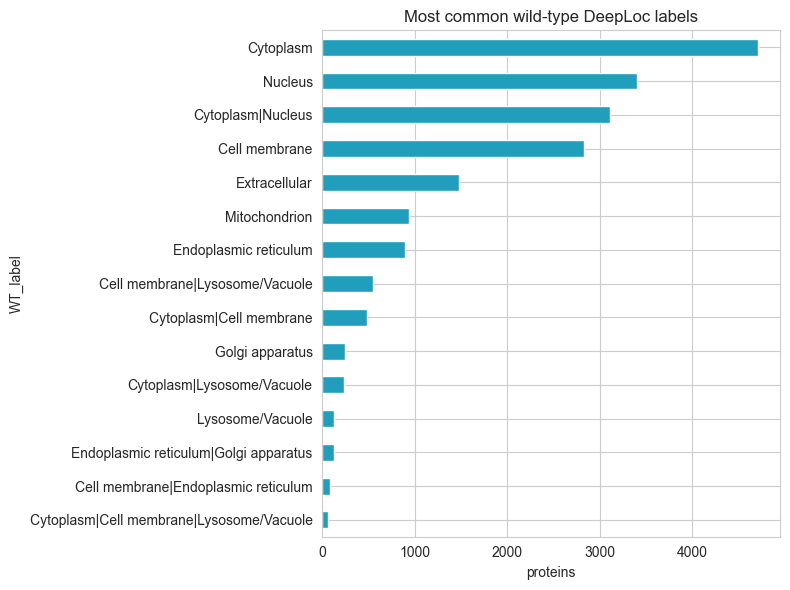

In [4]:
wt = df.drop_duplicates("accession")
top = wt["WT_label"].value_counts().head(15)
top.iloc[::-1].plot.barh(figsize=(8, 6), color="#219ebc")
plt.xlabel("proteins"); plt.title("Most common wild-type DeepLoc labels"); plt.tight_layout(); plt.show()

## How often does a variant change the predicted label?

In [5]:
print(f"Overall label_changed rate: {df['label_changed'].mean():.2%}")
by_cat = df.groupby("category")["label_changed"].agg(["mean", "size"]).sort_values("mean", ascending=False)
by_cat.rename(columns={"mean": "frac_label_changed", "size": "n"})

Overall label_changed rate: 4.03%


,frac_label_changed,n
category,,
nonsense,0.386916,276396
del,0.028786,25672
ins,0.025166,4212
delins,0.025049,4112
dup,0.019379,4025
missense,0.016333,3969042


## Variant effect (delta) distributions

`DELTA = mutant - WT` probability. Most variants should sit near zero; the tails are the interesting cases (log y-axis).

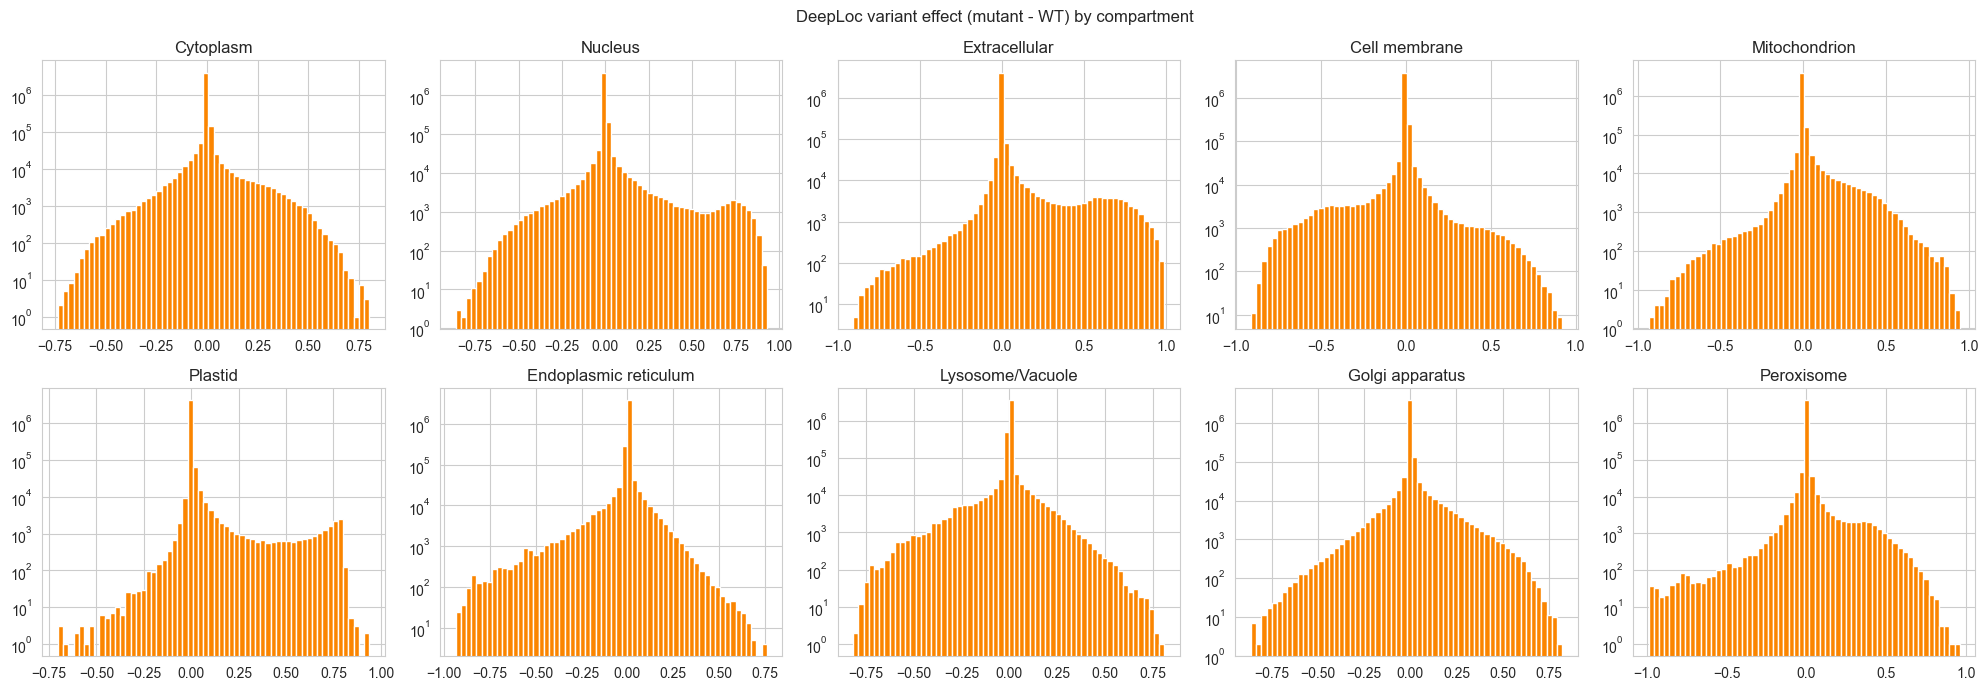

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(20, 7))
for ax, c in zip(axes.flat, LOCS):
    ax.hist(df[f"DELTA_{c}"], bins=60, color="#fb8500"); ax.set_yscale("log"); ax.set_title(c)
fig.suptitle("DeepLoc variant effect (mutant - WT) by compartment"); fig.tight_layout(); plt.show()

## Wild-type label to mutant label transitions

Among variants whose label changed: the most common transitions.

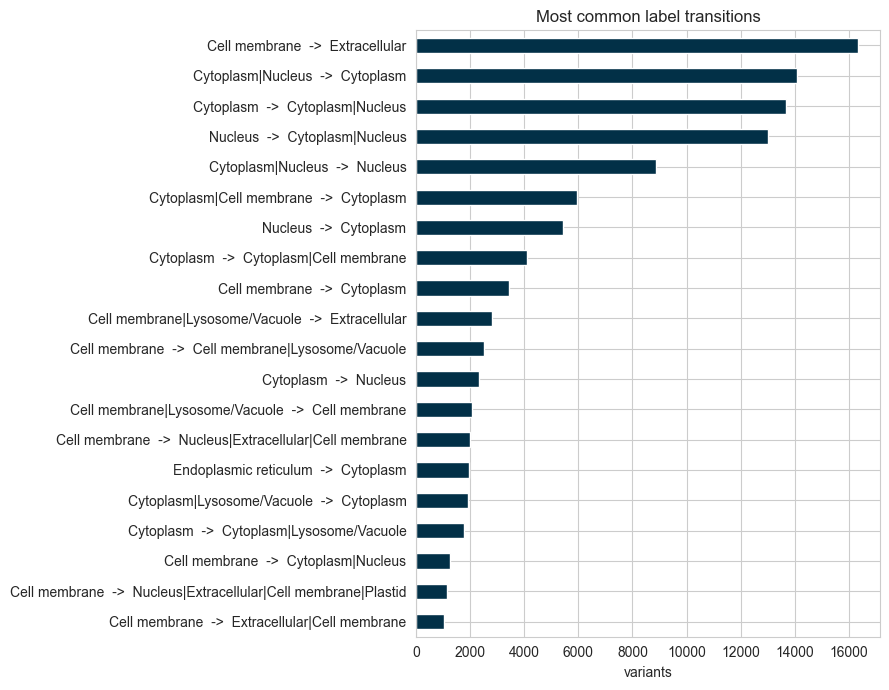

In [7]:
ch = df[df["label_changed"] == 1]
trans = (ch["WT_label"] + "  ->  " + ch["MUT_label"]).value_counts().head(20)
trans.iloc[::-1].plot.barh(figsize=(9, 7), color="#023047")
plt.xlabel("variants"); plt.title("Most common label transitions"); plt.tight_layout(); plt.show()

## Variants with the largest predicted localization shift

Ranked by the largest absolute delta across the 10 compartments.

In [8]:
dcols = [f"DELTA_{c}" for c in LOCS]
mx = df[dcols].abs().max(axis=1)
top = df.loc[mx.sort_values(ascending=False).index[:25]]
top[[ID, GENE, "category", "WT_label", "MUT_label"] + dcols]

,GENOMIC_MUTATION_ID,GENE_NAME,category,WT_label,MUT_label,DELTA_Cytoplasm,DELTA_Nucleus,DELTA_Extracellular,DELTA_Cell membrane,DELTA_Mitochondrion,DELTA_Plastid,DELTA_Endoplasmic reticulum,DELTA_Lysosome/Vacuole,DELTA_Golgi apparatus,DELTA_Peroxisome
2318137,COSV56994131,OTX1,missense,Nucleus,Nucleus|Extracellular,0.0991,-0.0220,0.9913,0.2107,0.0936,0.6187,-0.0177,-0.0253,0.1693,0.0836
2921306,COSV68304827,PLAA,missense,Cytoplasm|Nucleus,Cytoplasm|Nucleus|Extracellular|Cell membrane|...,-0.1624,0.2818,0.9907,0.4616,0.0781,0.3580,0.0769,-0.2765,0.2543,0.1976
2333164,COSV56429883,TRPC1,missense,Cell membrane,Cytoplasm|Nucleus|Extracellular|Cell membrane,0.3770,0.7857,0.9902,-0.1506,-0.1061,0.1041,-0.4636,0.0269,0.1704,0.0077
2921322,COSV68305825,PLAA,missense,Cytoplasm|Nucleus,Nucleus|Extracellular|Plastid,-0.4611,0.3749,0.9895,0.2250,0.0148,0.7729,-0.2306,-0.3739,-0.0268,-0.0035
2371323,COSV52999764,GADD45G,missense,Cytoplasm,Nucleus|Extracellular|Plastid,-0.2209,0.5015,0.9891,0.0351,0.1146,0.7387,-0.0357,-0.0770,0.2662,0.0236
2777449,COSV99392827,ACAD11,nonsense,Peroxisome,Cytoplasm|Nucleus,0.3755,0.3164,0.1003,0.1010,-0.3394,0.0139,0.0761,0.0638,-0.1367,-0.9891
2777269,COSV113303083,ACAD11,nonsense,Peroxisome,Cytoplasm|Nucleus,0.4184,0.2601,0.0939,0.0444,-0.0482,-0.0003,0.1186,0.1947,0.0346,-0.9882
2371301,COSV53000432,GADD45G,missense,Cytoplasm,Cytoplasm|Nucleus|Extracellular|Plastid,-0.1684,0.5232,0.9874,0.0484,0.1264,0.7323,-0.0355,-0.0782,0.2373,0.0183
2777451,COSV53901393,ACAD11,nonsense,Peroxisome,Nucleus,0.3269,0.2653,0.1609,0.0747,-0.1648,0.0205,0.0367,0.1964,-0.1853,-0.9873
2333452,COSV109573524,TRPC1,missense,Cell membrane,Nucleus|Extracellular|Cell membrane,0.2973,0.7716,0.9866,-0.0991,-0.0202,0.1305,-0.4815,-0.0210,0.1510,0.0052


## Genes with the most variants that shift localization

Counted as variants with any compartment delta of at least 0.5 in magnitude.

In [9]:
big = df[mx >= 0.5]
print(f"{len(big):,} variants ({len(big)/len(df):.2%}) with |delta| >= 0.5")
big[GENE].value_counts().head(20)

60,396 variants (1.41%) with |delta| >= 0.5


GENE_NAME
HCN1       831
GRM7       610
PCDHA12    577
GRIA2      576
PCDHA11    536
CNGB3      519
PCDHA9     507
PCDHAC2    468
PCDHGA8    455
CLCN1      443
MUC16      436
TRPC3      425
ENPEP      404
PCDHGB4    393
PCDHGB6    389
FAT1       381
ANKRD35    378
GABBR2     367
CD101      362
LGR6       351
Name: count, dtype: int64